In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
!pip install streamlit joblib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import joblib

In [3]:
df = pd.read_csv("European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df["Exited"].value_counts()
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

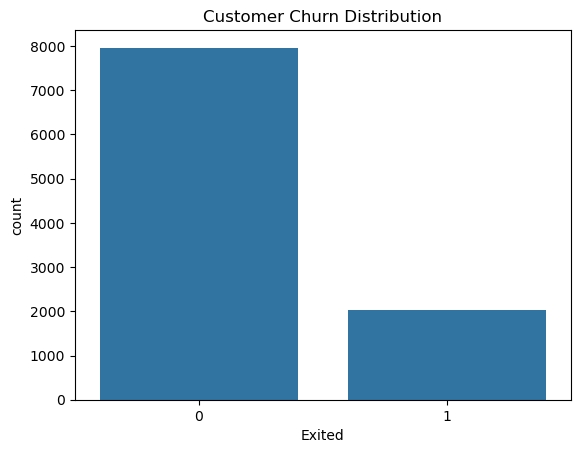

In [7]:
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [8]:
df = df.drop(columns=["CustomerId", "Surname"])

In [9]:
if "Year" in df.columns:
    print(df["Year"].nunique())

1


In [10]:
df = df.drop(columns=["Year"])

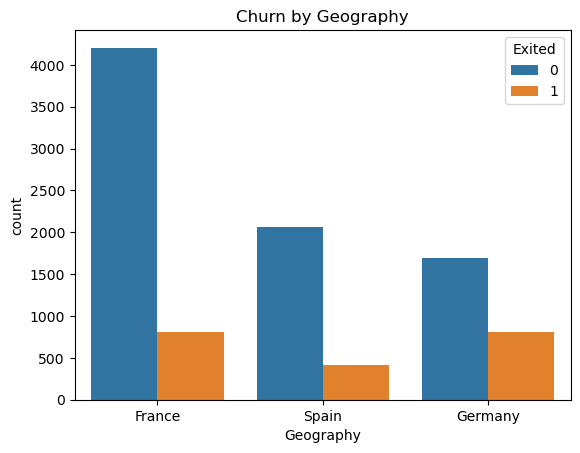

In [11]:
pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Geography")
plt.show()

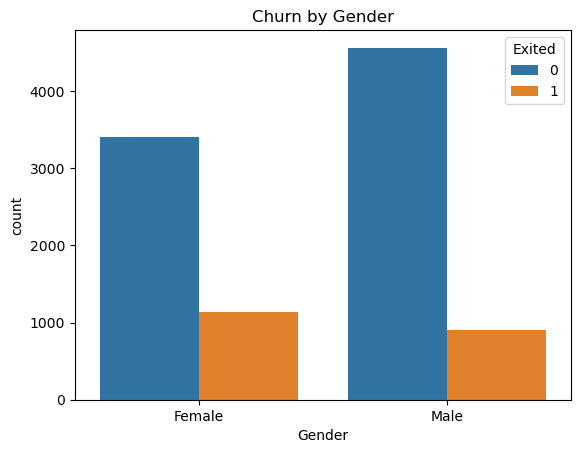

In [12]:
pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Churn by Gender")
plt.show()

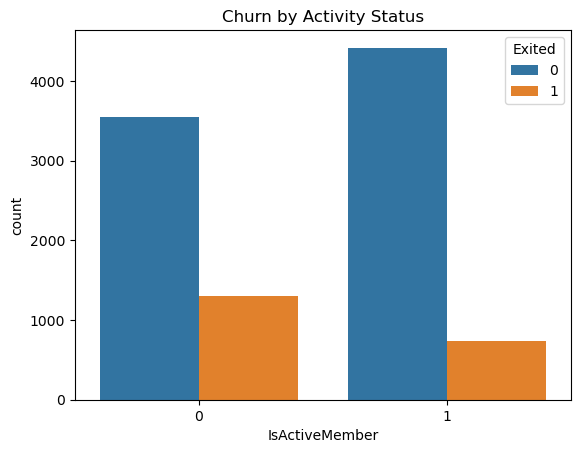

In [13]:
pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="index") * 100
sns.countplot(x="IsActiveMember", hue="Exited", data=df)
plt.title("Churn by Activity Status")
plt.show()

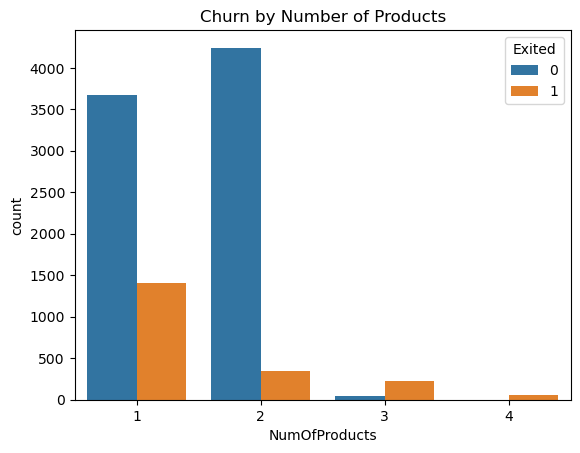

In [14]:
pd.crosstab(df["NumOfProducts"], df["Exited"], normalize="index") * 100
sns.countplot(x="NumOfProducts", hue="Exited", data=df)
plt.title("Churn by Number of Products")
plt.show()

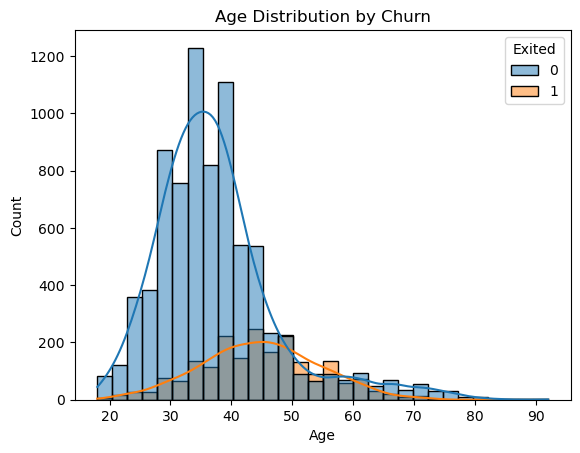

In [15]:
sns.histplot(data=df, x="Age", hue="Exited", kde=True, bins=30)
plt.title("Age Distribution by Churn")
plt.show()

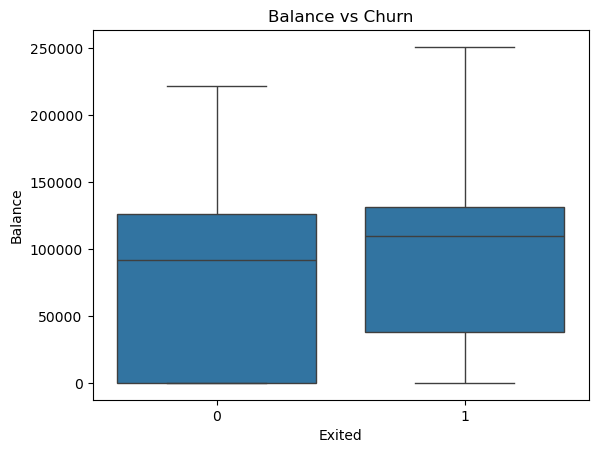

In [16]:
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

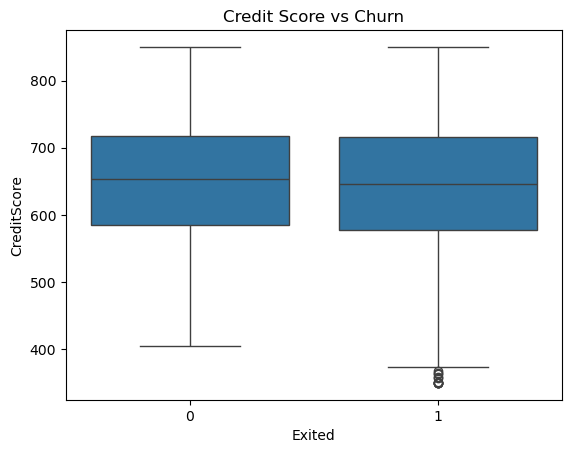

In [17]:
sns.boxplot(x="Exited", y="CreditScore", data=df)
plt.title("Credit Score vs Churn")
plt.show()

In [18]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["ProductDensity"] = df["NumOfProducts"] / (df["Tenure"] + 1)
df["EngagementProductInteraction"] = df["IsActiveMember"] * df["NumOfProducts"]
df["AgeTenureInteraction"] = df["Age"] * df["Tenure"]

In [19]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86


In [20]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [21]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Geography', 'Gender']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProductInteraction', 'AgeTenureInteraction']


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [25]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression
Accuracy: 0.806
Precision: 0.5703703703703704
Recall: 0.1891891891891892
F1: 0.28413284132841327
ROC-AUC: 0.7734853497565363


In [26]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
])

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy: 0.857
Precision: 0.7951219512195122
Recall: 0.4004914004914005
F1: 0.5326797385620915
ROC-AUC: 0.8441808526554289


In [27]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy: 0.8635
Precision: 0.793859649122807
Recall: 0.44471744471744473
F1: 0.5700787401574803
ROC-AUC: 0.8551818382326857


In [28]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting
Accuracy: 0.8685
Precision: 0.7857142857142857
Recall: 0.4864864864864865
F1: 0.6009104704097117
ROC-AUC: 0.8687747840290213


In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8060,0.570370,0.189189,0.284133,0.773485
1,Decision Tree,0.8570,0.795122,0.400491,0.532680,0.844181
2,Random Forest,0.8635,0.793860,0.444717,0.570079,0.855182
3,Gradient Boosting,0.8685,0.785714,0.486486,0.600910,0.868775


In [30]:
results.to_csv("model_comparison.csv", index=False)

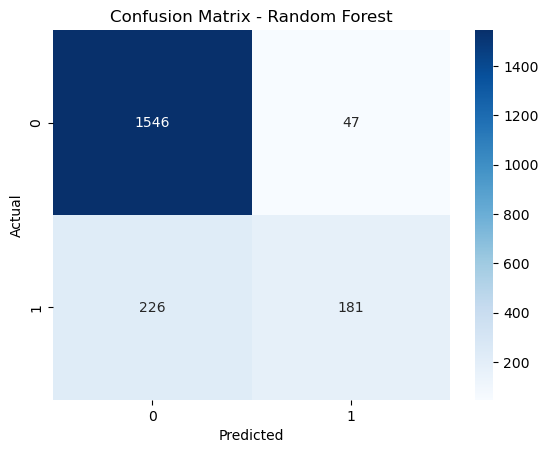

In [31]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



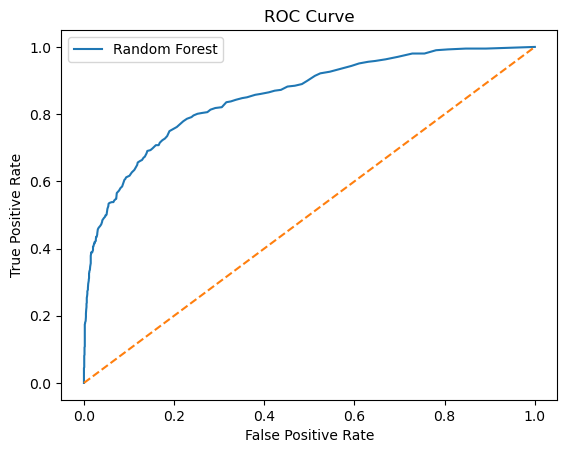

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
rf_pipeline = rf_model
rf_pipeline.fit(X_train, y_train)

ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(encoded_cat_names)

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
1,Age,0.207668
7,EstimatedSalary,0.096727
3,Balance,0.096339
0,CreditScore,0.096116
4,NumOfProducts,0.094434
11,AgeTenureInteraction,0.090076
8,BalanceSalaryRatio,0.079073
9,ProductDensity,0.053588
10,EngagementProductInteraction,0.045242
2,Tenure,0.040870


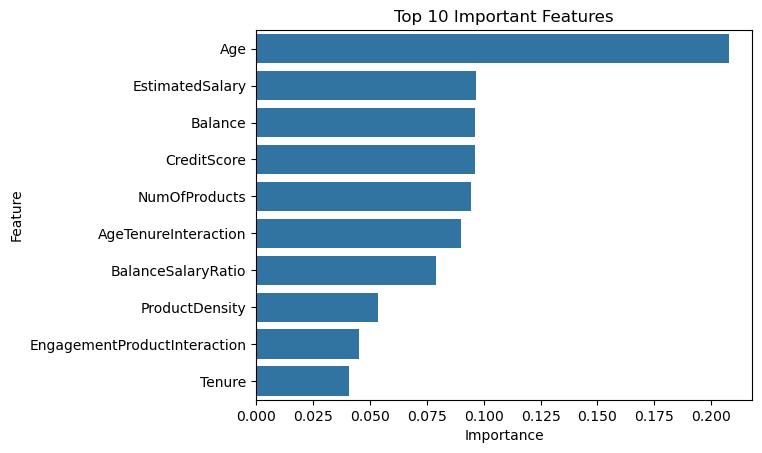

In [35]:
top10 = feature_importance_df.head(10)
sns.barplot(data=top10, x="Importance", y="Feature")
plt.title("Top 10 Important Features")
plt.show()

In [36]:
feature_importance_df.to_csv("feature_importance.csv", index=False)

In [37]:
final_model = rf_model   # or gb_model if that performs better
final_model.fit(X_train, y_train)

churn_probabilities = final_model.predict_proba(X)[:, 1]
df["ChurnProbability"] = churn_probabilities

In [38]:
def risk_bucket(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

df["RiskCategory"] = df["ChurnProbability"].apply(risk_bucket)

In [39]:
df[["ChurnProbability", "RiskCategory"]].head()

,ChurnProbability,RiskCategory
0,0.675,Medium Risk
1,0.125,Low Risk
2,0.950,High Risk
3,0.010,Low Risk
4,0.045,Low Risk


In [40]:
df.to_csv("bank_customers_with_risk_scores.csv", index=False)

In [41]:
joblib.dump(final_model, "bank_churn_model.pkl")

['bank_churn_model.pkl']